# FinOps Anomaly Detection: ML Pipeline & Analysis

This notebook demonstrates a complete Machine Learning pipeline for anomaly detection
using **Isolation Forest** on the full **~60k-row** processed billing dataset.
We load normalized multi-cloud billing data, engineer temporal features, train
an Isolation Forest model, and evaluate performance with real ground-truth labels.

## 1. Import Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Processed Data & Ground-Truth Labels

We load directly from `data/processed/daily_billing.csv` — the full ~60k-row
normalised dataset produced by the Phase-1 normalizer — and from
`data/raw/anomaly_labels.json` which contains the six injected anomaly windows.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
CSV_PATH    = "data/processed/daily_billing.csv"
LABELS_PATH = "data/raw/anomaly_labels.json"

# ── Load billing data ─────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, parse_dates=["date"])

print(f"Loaded {len(df):,} billing rows")
print(f"Date range : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Providers  : {sorted(df['provider'].unique())}")
print(f"Services   : {df['service'].nunique()} unique")

display(df.head())

Loaded 59,730 billing rows
Date range : 2025-10-16 -> 2026-04-14
Providers  : ['aws', 'azure', 'gcp']
Services   : 9 unique


,date,provider,service,category,team,environment,region,cost_usd
0,2025-10-16,aws,CDN,networking,backend,development,us-east,14.7545
1,2025-10-16,azure,Virtual Machines,compute,platform,staging,asia-southeast,253.9194
2,2025-10-16,azure,Virtual Machines,compute,platform,production,asia-southeast,244.6536
3,2025-10-16,azure,Virtual Machines,compute,platform,development,asia-southeast,258.6896
4,2025-10-16,azure,Virtual Machines,compute,ml-team,staging,eu-west,270.5480


### Create Ground-Truth Labels

The JSON labels store the *raw* service names (e.g. `Amazon EC2`).
The processed CSV already maps those to canonical names (e.g. `Virtual Machines`).
We apply the same `SERVICE_CANONICAL` mapping used by `normalizer.py` so the join works correctly.

In [3]:
# Same mapping as normalizer.py
SERVICE_CANONICAL = {
    "Amazon EC2":               "Virtual Machines",
    "Virtual Machines":         "Virtual Machines",
    "Compute Engine":           "Virtual Machines",
    "Amazon EKS":               "Kubernetes",
    "Azure Kubernetes Service": "Kubernetes",
    "Kubernetes Engine":        "Kubernetes",
    "AWS Lambda":               "Serverless Functions",
    "Azure Functions":          "Serverless Functions",
    "Cloud Run":                "Serverless Functions",
    "Amazon S3":                "Object Storage",
    "Azure Blob Storage":       "Object Storage",
    "Cloud Storage":            "Object Storage",
    "Amazon RDS":               "Managed Database",
    "Azure SQL Database":       "Managed Database",
    "Cloud SQL":                "Managed Database",
    "Amazon DynamoDB":          "NoSQL Database",
    "Amazon CloudFront":        "CDN",
    "Azure CDN":                "CDN",
    "AWS Data Transfer":        "Data Transfer",
    "Azure Bandwidth":          "Data Transfer",
    "Networking":               "Data Transfer",
    "BigQuery":                 "Data Analytics",
}

# Load labels
with open(LABELS_PATH) as f:
    raw_labels = json.load(f)

labels = pd.DataFrame(raw_labels)
# JSON uses 'start'/'end' keys
labels["start_date"] = pd.to_datetime(labels["start"])
labels["end_date"]   = pd.to_datetime(labels["end"])
# Map raw service names -> canonical
labels["service_canonical"] = labels["service"].map(SERVICE_CANONICAL).fillna(labels["service"])

print(f"Loaded {len(labels)} anomaly label windows")
display(labels[["id", "provider", "service", "service_canonical",
                "start_date", "end_date", "type", "description"]])

Loaded 6 anomaly label windows


,id,provider,service,service_canonical,start_date,end_date,type,description
0,ANO-001,aws,Amazon EC2,Virtual Machines,2026-01-24,2026-01-30,spike,EC2 autoscaling loop caused by failed health c...
1,ANO-002,aws,Amazon S3,Object Storage,2025-12-15,2026-01-14,gradual_drift,S3 backup job misconfigured — storing duplicates
2,ANO-003,azure,Virtual Machines,Virtual Machines,2026-02-23,2026-03-01,spike,Dev VMs not shut down over weekend
3,ANO-004,azure,Azure Bandwidth,Data Transfer,2026-03-15,2026-03-19,correlated,Public bucket exposure causing egress spike
4,ANO-005,gcp,BigQuery,Data Analytics,2026-02-13,2026-02-16,spike,Runaway BigQuery scan without partition filter
5,ANO-006,gcp,Kubernetes Engine,Kubernetes,2025-11-25,2026-01-04,gradual_drift,GKE node pool not autoscaling down after load ...


In [4]:
# ── Label join ────────────────────────────────────────────────────────────────
df["is_anomaly"] = 0

for _, row in labels.iterrows():
    mask = (
        (df["date"] >= row["start_date"]) &
        (df["date"] <= row["end_date"]) &
        (df["provider"] == row["provider"]) &
        (df["service"]  == row["service_canonical"])
    )
    # team filter only if label specifies one
    if pd.notna(row.get("team")) and str(row.get("team", "")).strip():
        mask = mask & (df["team"] == row["team"])
    df.loc[mask, "is_anomaly"] = 1

# target: 1 = Normal, -1 = Anomaly  (sklearn convention)
df["target"] = df["is_anomaly"].apply(lambda x: -1 if x == 1 else 1)

n_anom = df["is_anomaly"].sum()
print("Ground-Truth Distribution:")
print(df["is_anomaly"].value_counts())
print(f"\nAnomaly rate: {100*n_anom/len(df):.2f}%  ({n_anom:,} / {len(df):,} rows)")

Ground-Truth Distribution:
is_anomaly
0    59301
1      429
Name: count, dtype: int64

Anomaly rate: 0.72%  (429 / 59,730 rows)


## 3. Exploratory Data Analysis (EDA)

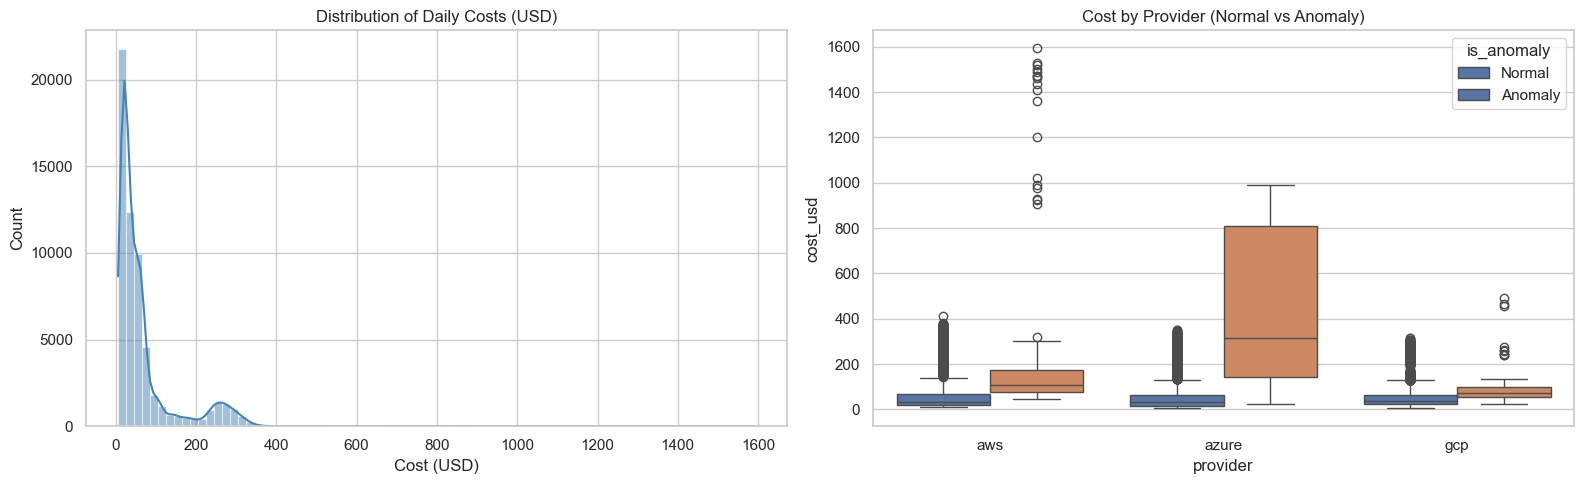

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cost distribution
sns.histplot(df["cost_usd"], bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Daily Costs (USD)")
axes[0].set_xlabel("Cost (USD)")

# Cost by provider, colour by anomaly
sns.boxplot(data=df, x="provider", y="cost_usd", hue="is_anomaly",
            palette={0: "#4C72B0", 1: "#DD8452"}, ax=axes[1])
axes[1].set_title("Cost by Provider (Normal vs Anomaly)")
axes[1].legend(title="is_anomaly", labels=["Normal", "Anomaly"])

plt.tight_layout()
plt.show()

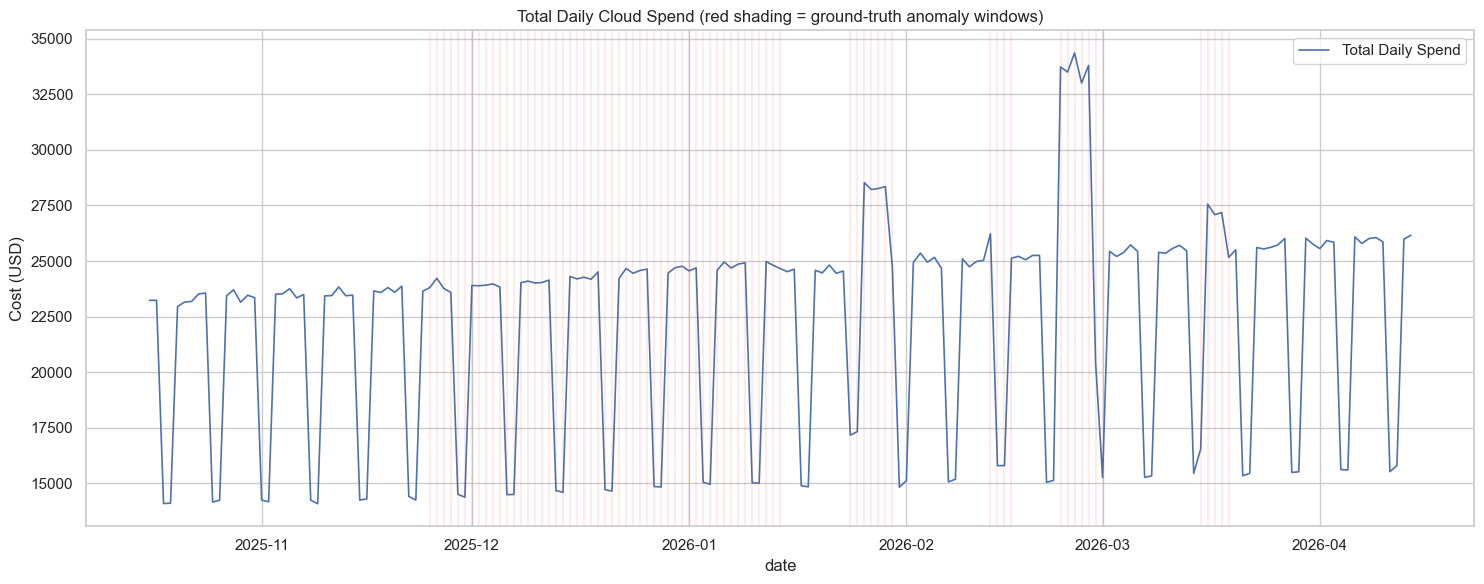

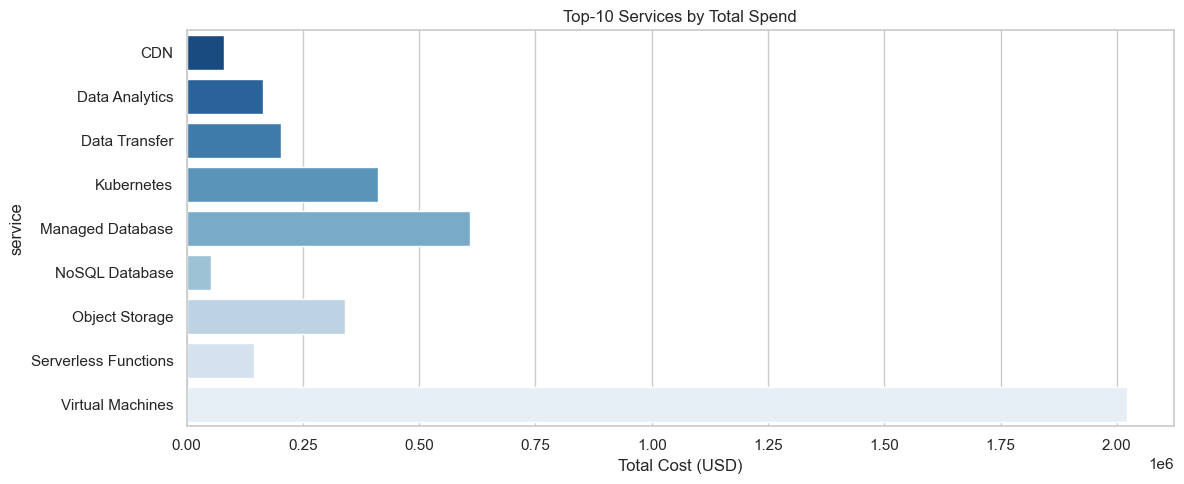

In [6]:
# Time-series: total daily spend with anomaly highlights
daily_total     = df.groupby("date")["cost_usd"].sum().reset_index()
anomaly_dates   = df[df["is_anomaly"] == 1]["date"].unique()

plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_total, x="date", y="cost_usd", label="Total Daily Spend", linewidth=1.2)
for d in anomaly_dates:
    plt.axvline(d, color="red", alpha=0.08)
plt.title("Total Daily Cloud Spend (red shading = ground-truth anomaly windows)")
plt.ylabel("Cost (USD)")
plt.tight_layout()
plt.show()

# Spend by service
top_services = df.groupby("service")["cost_usd"].sum().nlargest(10).index
plt.figure(figsize=(12, 5))
df_top = df[df["service"].isin(top_services)]
sns.barplot(data=df_top.groupby("service", as_index=False)["cost_usd"].sum(),
            x="cost_usd", y="service", palette="Blues_r")
plt.title("Top-10 Services by Total Spend")
plt.xlabel("Total Cost (USD)")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

We build the same rich feature set used by `anomaly_detector.py`:
temporal features + 7-day and 30-day rolling statistics per `(provider, service, team, environment)` group,
plus the cost-ratio relative to the rolling mean.

In [7]:
df = df.sort_values(["provider", "service", "team", "environment", "date"]).reset_index(drop=True)
grp_cols = ["provider", "service", "team", "environment"]

# Temporal
df["dayofweek"]  = df["date"].dt.dayofweek
df["dayofmonth"] = df["date"].dt.day
df["month"]      = df["date"].dt.month
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

# Rolling features (shift-1 to avoid data leakage)
g = df.groupby(grp_cols, observed=True)["cost_usd"]

df["roll7_mean"]  = g.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
df["roll7_std"]   = g.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).std().fillna(0))
df["roll30_mean"] = g.transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())

df["cost_vs_roll7"]  = df["cost_usd"] / df["roll7_mean"].replace(0, np.nan).fillna(1)
df["cost_vs_roll30"] = df["cost_usd"] / df["roll30_mean"].replace(0, np.nan).fillna(1)

# Encode categoricals
for col in grp_cols:
    df[f"{col}_code"] = df[col].astype("category").cat.codes

df = df.dropna().reset_index(drop=True)

FEATURES = [
    "cost_usd", "dayofweek", "dayofmonth", "month", "weekofyear",
    "roll7_mean", "roll7_std", "roll30_mean",
    "cost_vs_roll7", "cost_vs_roll30",
    "provider_code", "service_code", "team_code", "environment_code",
]

X = df[FEATURES]
y = df["target"]

print(f"Feature matrix : {X.shape}")
print(f"Anomaly rows   : {(y == -1).sum():,} / {len(y):,}  ({100*(y==-1).mean():.2f}%)")
print("\nSample features:")
display(X.head())

Feature matrix : (59400, 14)
Anomaly rows   : 429 / 59,400  (0.72%)

Sample features:


,cost_usd,dayofweek,dayofmonth,month,weekofyear,roll7_mean,roll7_std,roll30_mean,cost_vs_roll7,cost_vs_roll30,provider_code,service_code,team_code,environment_code
0,18.9379,4,17,10,42,14.7545,0.000000,14.7545,1.283534,1.283534,0,0,0,0
1,13.4184,5,18,10,42,16.8462,2.958111,16.8462,0.796524,0.796524,0,0,0,0
2,13.6188,6,19,10,42,15.7036,2.879551,15.7036,0.867241,0.867241,0,0,0,0
3,19.2219,0,20,10,43,15.1824,2.571862,15.1824,1.266065,1.266065,0,0,0,0
4,16.6200,1,21,10,43,15.9903,2.867816,15.9903,1.039380,1.039380,0,0,0,0


## 5. Chronological Train / Test Split & Model Training

In [8]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_test = df.iloc[split_idx:].copy()

# Split date ranges
train_dates = df.iloc[:split_idx]["date"]
test_dates  = df.iloc[split_idx:]["date"]
print(f"Train: {len(X_train):,} rows  |  {train_dates.min().date()} -> {train_dates.max().date()}  "
      f"|  anomalies: {(y_train == -1).sum():,}")
print(f"Test : {len(X_test):,} rows   |  {test_dates.min().date()}  -> {test_dates.max().date()}  "
      f"|  anomalies: {(y_test == -1).sum():,}")

# Contamination = actual anomaly rate in training set
contamination = float(np.clip((y_train == -1).sum() / len(y_train), 0.01, 0.5))
print(f"\nContamination  : {contamination:.4f}")

# Build and fit pipeline
pipeline = Pipeline([
    ("scaler",  StandardScaler()),
    ("iforest", IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
    ))
])

print("\nTraining Isolation Forest (n_estimators=200) ...")
pipeline.fit(X_train)

y_pred = pipeline.predict(X_test)
df_test["pred_target"] = y_pred

print("Done.")
pred_counts = pd.Series(y_pred).value_counts().rename({1: "Normal (1)", -1: "Anomaly (-1)"})
print("\nPredictions on test set:")
print(pred_counts)

Train: 47,520 rows  |  2025-10-17 -> 2026-04-14  |  anomalies: 306
Test : 11,880 rows   |  2025-10-17  -> 2026-04-14  |  anomalies: 123

Contamination  : 0.0100

Training Isolation Forest (n_estimators=200) ...
Done.

Predictions on test set:
Normal (1)      11660
Anomaly (-1)      220
Name: count, dtype: int64


## 6. Evaluation Metrics

### Detected Anomalies — Sample View

In [9]:
detected = df_test[df_test["pred_target"] == -1].copy()
detected["true_anomaly"] = (df_test["target"] == -1).values

print(f"Total rows flagged by model : {len(detected):,}")
print(f"  of which are true anomalies: {detected['true_anomaly'].sum():,}  "
      f"(TP={detected['true_anomaly'].sum()}, FP={len(detected)-detected['true_anomaly'].sum()})")

display(
    detected[["date", "provider", "service", "team", "environment",
              "cost_usd", "roll7_mean", "true_anomaly"]]
    .sort_values("cost_usd", ascending=False)
    .head(20)
)

ValueError: Length of values (11880) does not match length of index (220)

### Forecasting Baseline: MAE & RMSE (Normal rows only)

In [ ]:
normal_test = df_test[df_test["target"] == 1]

if len(normal_test) > 0:
    mae  = mean_absolute_error(normal_test["cost_usd"], normal_test["roll7_mean"])
    rmse = np.sqrt(mean_squared_error(normal_test["cost_usd"], normal_test["roll7_mean"]))
    print(f"Normal rows in test   : {len(normal_test):,}")
    print(f"MAE  (actual vs 7-day rolling mean) : ${mae:.2f}")
    print(f"RMSE (actual vs 7-day rolling mean) : ${rmse:.2f}")
else:
    print("No normal rows in test set.")

Normal rows in test   : 11,757
MAE  (actual vs 7-day rolling mean) : $16.84
RMSE (actual vs 7-day rolling mean) : $27.20


## 7. Overfitting / Underfitting — Validation Curve

We vary `n_estimators` and track Train vs Test F1 to check for over/under-fitting.

Evaluating n_estimators...
  n=  10  train_F1=0.1671  test_F1=0.0000
  n=  50  train_F1=0.3274  test_F1=0.0000
  n= 100  train_F1=0.3402  test_F1=0.0072
  n= 200  train_F1=0.3376  test_F1=0.0000
  n= 300  train_F1=0.3350  test_F1=0.0000
  n= 500  train_F1=0.3376  test_F1=0.0000


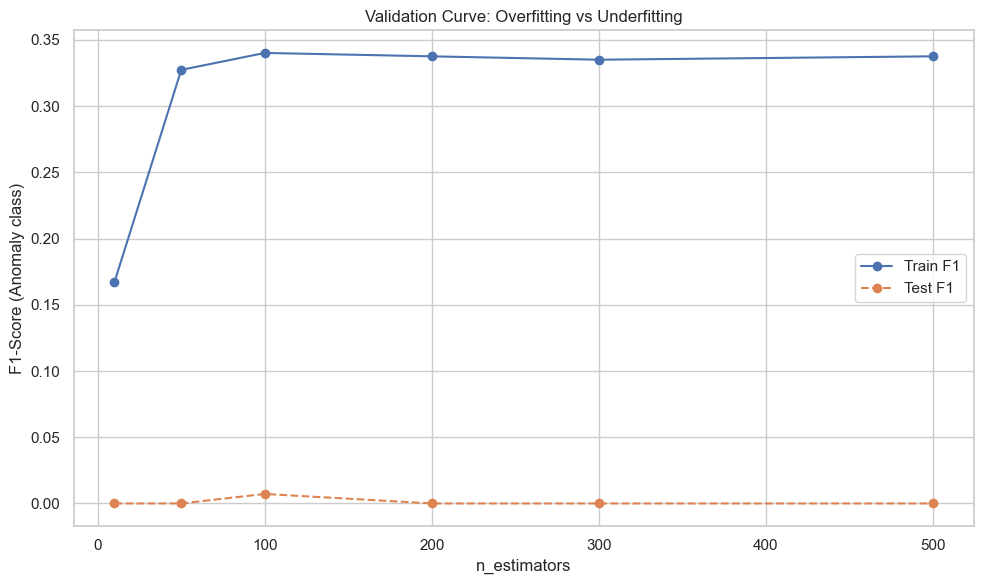

In [ ]:
if (y_test == -1).sum() == 0 or (y_train == -1).sum() == 0:
    print("Skipping validation curve — one split has no anomalies.")
else:
    estimators = [10, 50, 100, 200, 300, 500]
    train_f1, test_f1 = [], []

    print("Evaluating n_estimators...")
    for n in estimators:
        pipe = Pipeline([
            ("scaler",  StandardScaler()),
            ("iforest", IsolationForest(
                n_estimators=n,
                contamination=contamination,
                random_state=42,
                n_jobs=-1,
            ))
        ])
        pipe.fit(X_train)
        train_f1.append(f1_score(y_train, pipe.predict(X_train), pos_label=-1, zero_division=0))
        test_f1.append( f1_score(y_test,  pipe.predict(X_test),  pos_label=-1, zero_division=0))
        print(f"  n={n:4d}  train_F1={train_f1[-1]:.4f}  test_F1={test_f1[-1]:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(estimators, train_f1, marker="o", label="Train F1")
    plt.plot(estimators, test_f1,  marker="o", linestyle="--", label="Test F1")
    plt.xlabel("n_estimators")
    plt.ylabel("F1-Score (Anomaly class)")
    plt.title("Validation Curve: Overfitting vs Underfitting")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Interpreting the curve:**
- **Train F1 >> Test F1** → overfitting (reduce `n_estimators` or increase `contamination`).
- **Both low** → underfitting (add more features or lower `contamination`).
- **Converged & high** → well-generalised model.